In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:

X_train = pd.read_csv('X_train.csv')
Y_train = pd.read_csv('Y_train.csv')
X_test = pd.read_csv('X_test.csv')

print("✅ Archivos cargados exitosamente.")
print(f"X_train tiene {X_train.shape[0]} filas y {X_train.shape[1]} columnas.")
print(f"Y_train tiene {Y_train.shape[0]} filas y {Y_train.shape[1]} columnas.")
print(f"X_test tiene {X_test.shape[0]} filas y {X_test.shape[1]} columnas.")


✅ Archivos cargados exitosamente.
X_train tiene 132 filas y 49 columnas.
Y_train tiene 132 filas y 4 columnas.
X_test tiene 24 filas y 49 columnas.


In [4]:
# --- 2. Exploración de X_train (Features) ---

print("\nPrimeras 5 filas de X_train:")
display(X_train)

X_train.info()

# Resumen estadístico de variables numéricas
print(X_train.describe())

# Resumen estadístico de variables categóricas
print(X_train.describe(include=['object']))

# Conteo de valores nulos (NaN)
# Filtramos solo las columnas que SÍ tienen nulos para un reporte más limpio
missing_values = X_train.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))
if missing_values.sum() == 0:
    print("¡No hay valores nulos en X_train!")


Primeras 5 filas de X_train:


,fecha,edad,sexo,origen antepasados (españa),origen antepasados (extranjeros),hº deporte sem,hº naturaleza sem,hº ocio exteriores sem,horas exterior sem,hº estudiar sem,...,OS-DS,CUVAF-Total,CUVAF-Media,CUVAF-DS,Promedio Nasal,DE Nasal,Suma Nasal,Promedio Temporal,DE Temporal,Suma Temporal
0,2/11/20,22,Mujer,Asturias,NaN,0.0,0.0,4.0,4.0,40,...,0.238059,2.256667,0.564167,0.842300,0.905000,1.279863,1.810000,0.223333,0.160278,0.446667
1,2/17/20,23,Mujer,Navarra,NaN,5.0,2.0,2.0,9.0,20,...,2.585654,8.026667,2.006667,1.887316,3.620833,0.503224,7.241667,0.392500,0.102530,0.785000
2,3/10/20,22,Mujer,Bizkaia,NaN,2.0,3.0,8.0,13.0,30,...,0.431335,12.710000,3.177500,0.743668,3.152500,1.248043,6.305000,3.202500,0.314663,6.405000
3,2/26/20,22,Mujer,"Navarra, Extremadura, Cataluña, Aragón",España,0.0,2.0,13.0,15.0,54,...,0.626968,3.551667,0.887917,0.877145,1.003333,1.418928,2.006667,0.772500,0.491439,1.545000
4,2/19/20,23,Mujer,Toledo,NaN,3.0,0.0,0.0,3.0,56,...,1.269257,1.795000,0.448750,0.897500,0.897500,1.269257,1.795000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,2/10/20,22,Mujer,Alicante,NaN,12.0,0.0,2.0,14.0,30,...,0.289914,1.726667,0.431667,0.415732,0.498333,0.704750,0.996667,0.365000,0.063640,0.730000
128,2/18/20,23,Hombre,Badajoz y Navarra,NaN,4.5,0.0,0.0,4.5,55,...,3.266833,27.686667,6.921667,3.145054,4.515000,1.935116,9.030000,9.328333,1.661701,18.656667
129,2/26/20,22,Mujer,Navarra,NaN,10.0,0.0,4.0,14.0,30,...,3.857267,8.040000,2.010000,2.565778,0.312500,0.045962,0.625000,3.707500,2.867318,7.415000
130,2/18/20,24,Mujer,Navarra/Jaén,NaN,0.0,0.0,5.0,5.0,49,...,1.955150,3.535000,0.883750,1.305638,0.000000,0.000000,0.000000,1.767500,1.410678,3.535000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   fecha                             132 non-null    object 
 1   edad                              132 non-null    int64  
 2   sexo                              132 non-null    object 
 3   origen antepasados (españa)       130 non-null    object 
 4   origen antepasados (extranjeros)  34 non-null     object 
 5   hº deporte sem                    132 non-null    float64
 6   hº naturaleza sem                 132 non-null    float64
 7   hº ocio exteriores sem            130 non-null    float64
 8   horas exterior sem                132 non-null    float64
 9   hº estudiar sem                   132 non-null    int64  
 10  hº ocio inter sem                 132 non-null    int64  
 11  hº act.cerca sem                  0 non-null      float64
 12  horas in


Primeras 5 filas de Y_train:
    M  MM Combo DCombo
0  SI  SI    MM     MM
1  SI  NO     M     M1
2  NO  NO     C      C
3  NO  NO     C      C
4  NO  NO     C      C
M         0
MM        0
Combo     0
DCombo    0
dtype: int64

--- M (Miopía) ---
M
SI    66.666667
NO    33.333333
Name: proportion, dtype: float64

--- MM (Miopía Magna) ---
MM
NO    92.424242
SI     7.575758
Name: proportion, dtype: float64

--- Combo (C, M, MM) ---
Combo
M     53.030303
C     33.333333
MM    13.636364
Name: proportion, dtype: float64

--- DCombo (C, M1, M2, MM) ---
DCombo
C     33.333333
M1    29.545455
M2    23.484848
MM    13.636364
Name: proportion, dtype: float64


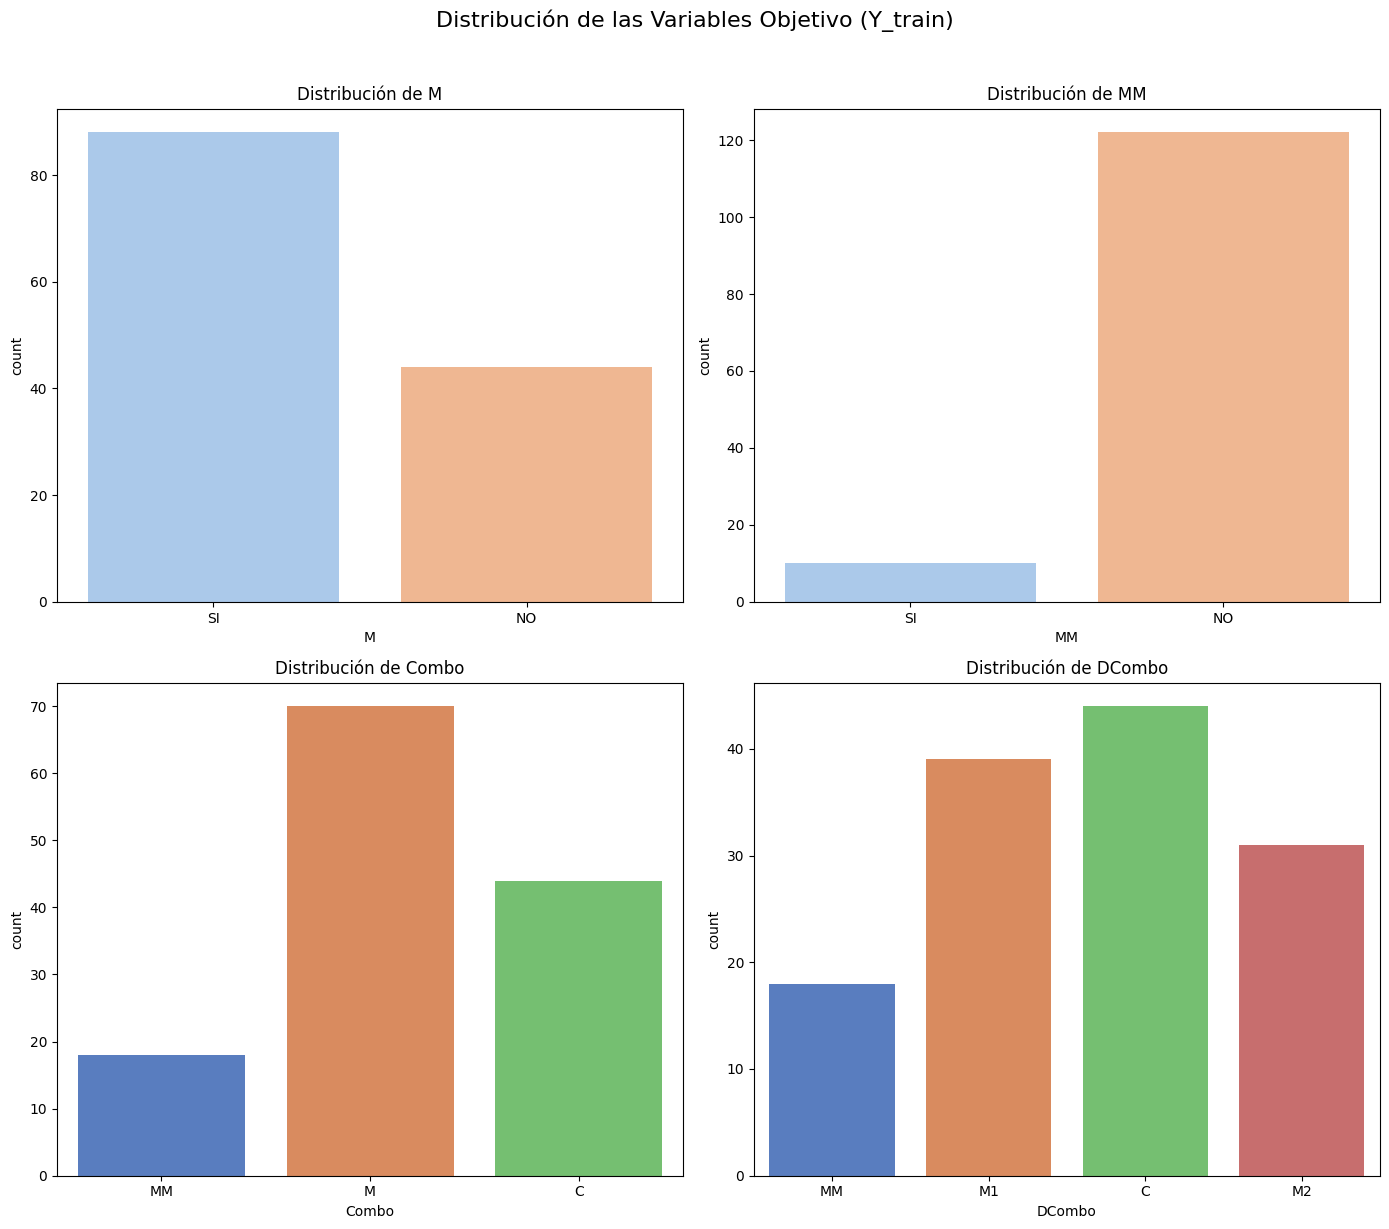


--- Fin de la Exploración Inicial ---


In [5]:
# Vistazo rápido a los targets
print("\nPrimeras 5 filas de Y_train:")
print(Y_train.head())

# Conteo de nulos en los targets (no debería haber)
print(Y_train.isnull().sum())

# --- Distribución de Clases (¡Muy importante!) ---

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Distribución de las Variables Objetivo (Y_train)', fontsize=16, y=1.02)

# Gráfico para 'M' (Miopía)
col_M = 'M'
if col_M in Y_train.columns:
    print(f"\n--- {col_M} (Miopía) ---")
    print(Y_train[col_M].value_counts(normalize=True) * 100)
    sns.countplot(ax=axes[0, 0], x=col_M, data=Y_train, palette='pastel')
    axes[0, 0].set_title(f'Distribución de {col_M}')

# Gráfico para 'MM' (Miopía Magna)
col_MM = 'MM'
if col_MM in Y_train.columns:
    print(f"\n--- {col_MM} (Miopía Magna) ---")
    print(Y_train[col_MM].value_counts(normalize=True) * 100)
    sns.countplot(ax=axes[0, 1], x=col_MM, data=Y_train, palette='pastel')
    axes[0, 1].set_title(f'Distribución de {col_MM}')

# Gráfico para 'Combo'
col_Combo = 'Combo'
if col_Combo in Y_train.columns:
    print(f"\n--- {col_Combo} (C, M, MM) ---")
    print(Y_train[col_Combo].value_counts(normalize=True) * 100)
    sns.countplot(ax=axes[1, 0], x=col_Combo, data=Y_train, palette='muted')
    axes[1, 0].set_title(f'Distribución de {col_Combo}')

# Gráfico para 'DCombo'
col_DCombo = 'DCombo'
if col_DCombo in Y_train.columns:
    print(f"\n--- {col_DCombo} (C, M1, M2, MM) ---")
    print(Y_train[col_DCombo].value_counts(normalize=True) * 100)
    sns.countplot(ax=axes[1, 1], x=col_DCombo, data=Y_train, palette='muted')
    axes[1, 1].set_title(f'Distribución de {col_DCombo}')

plt.tight_layout()
plt.show()

print("\n--- Fin de la Exploración Inicial ---")

--- 📊 Análisis de Valores Faltantes (X_train) ---
hº act.cerca sem                    100.000000
origen antepasados (extranjeros)     74.242424
Grupo fot                            18.181818
fototipo                             15.909091
Familiar miope num.                   3.030303
origen antepasados (españa)           1.515152
pat. Ret. Miop magna                  1.515152
hº ocio exteriores sem                1.515152
horas interior sem                    0.757576
familiar miope                        0.757576
dtype: float64




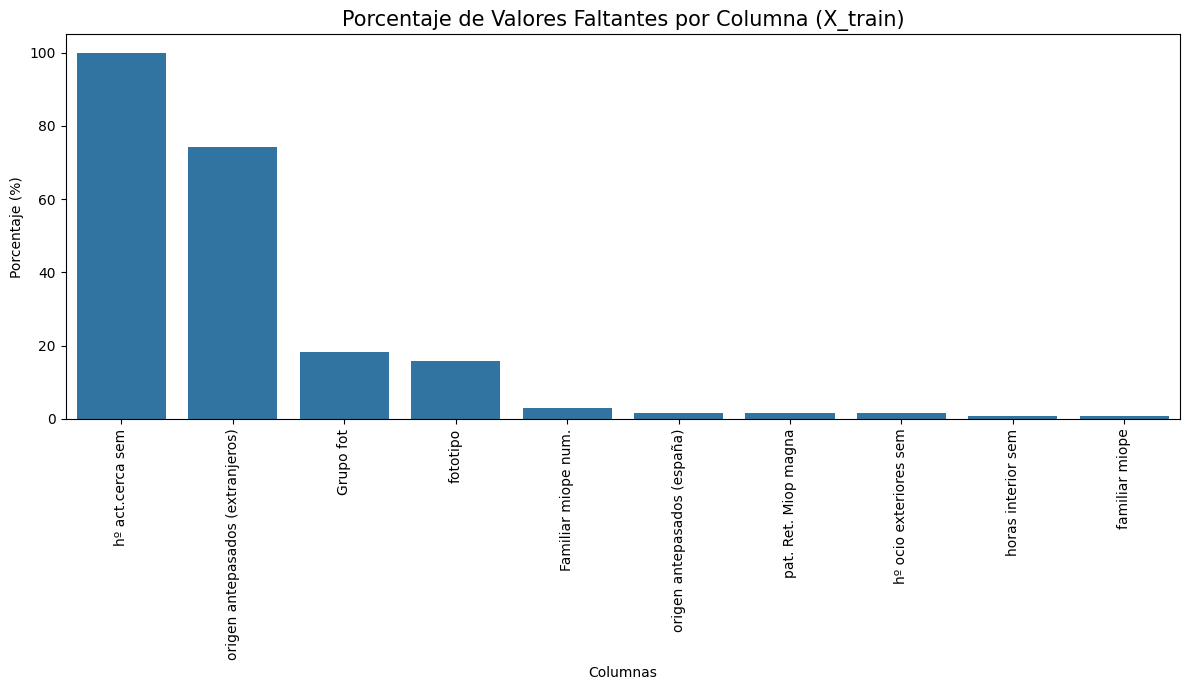


--- 🧹 Iniciando Limpieza y Preprocesamiento ---
Columnas eliminadas: ['hº act.cerca sem', 'origen antepasados (extranjeros)', 'fecha']
Columnas numéricas imputadas con la MEDIANA: ['Familiar miope num.', 'hº ocio exteriores sem', 'horas interior sem']
Columnas categóricas imputadas con la MODA: ['Grupo fot', 'fototipo', 'origen antepasados (españa)', 'pat. Ret. Miop magna', 'familiar miope']

--- ✅ Verificación Post-Limpieza ---
¡Atención! Quedan 0 nulos en X_train_proc.
¡Atención! Quedan 2 nulos en X_test_proc.

Dimensiones finales de X_train_proc: (132, 46)
Dimensiones finales de X_test_proc: (24, 46)


In [6]:
# --- 1. Análisis Visual de Valores Faltantes ---

# Calculamos el porcentaje de nulos solo para columnas que SÍ tienen nulos
missing_percent = (X_train.isnull().sum() / len(X_train)) * 100
missing_data = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- 📊 Análisis de Valores Faltantes (X_train) ---")
print(missing_data)
print("\n")

# Graficamos
plt.figure(figsize=(12, 7))
sns.barplot(x=missing_data.index, y=missing_data.values)
plt.xticks(rotation=90)
plt.title('Porcentaje de Valores Faltantes por Columna (X_train)', fontsize=15)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.tight_layout()
plt.show()

# --- 2. Creación de Copias para Preprocesamiento ---
# (Buena práctica para no modificar los dataframes originales)

X_train_proc = X_train.copy()
X_test_proc = X_test.copy()

print("\n--- 🧹 Iniciando Limpieza y Preprocesamiento ---")

# --- 3. Estrategia de Limpieza y Relleno (Imputación) ---

# --- Nivel 1: Columnas a ELIMINAR ---
# (Columnas 100% vacías, con demasiados nulos, o irrelevantes)
cols_to_drop = [
    'hº act.cerca sem',                 # 100% nulos
    'origen antepasados (extranjeros)', # ~74% nulos, imposible rellenar
    'fecha'                             # Categórica irrelevante para la predicción
]

X_train_proc = X_train_proc.drop(columns=cols_to_drop)
# Aplicamos la MISMA transformación a X_test
X_test_proc = X_test_proc.drop(columns=cols_to_drop)

print(f"Columnas eliminadas: {cols_to_drop}")

# --- Nivel 2: Relleno (Imputación) de Columnas NUMÉRICAS ---
# Usamos la MEDIANA (más robusta a outliers que la media)
cols_num_impute = [
    'Familiar miope num.',
    'hº ocio exteriores sem',
    'horas interior sem'
]

for col in cols_num_impute:
    # 1. Calculamos la mediana del set de ENTRENAMIENTO
    median_value = X_train_proc[col].median()

    # 2. Rellenamos X_train con esa mediana
    X_train_proc[col] = X_train_proc[col].fillna(median_value)

    # 3. Rellenamos X_test con la mediana de X_train (Evita "data leakage")
    X_test_proc[col] = X_test_proc[col].fillna(median_value)

print(f"Columnas numéricas imputadas con la MEDIANA: {cols_num_impute}")

# --- Nivel 3: Relleno (Imputación) de Columnas CATEGÓRICAS ---
# Usamos la MODA (el valor más frecuente)
cols_cat_impute = [
    'Grupo fot',
    'fototipo',
    'origen antepasados (españa)',
    'pat. Ret. Miop magna',
    'familiar miope'
]

for col in cols_cat_impute:
    # 1. Calculamos la moda del set de ENTRENAMIENTO
    mode_value = X_train_proc[col].mode()[0]

    # 2. Rellenamos X_train con esa moda
    X_train_proc[col] = X_train_proc[col].fillna(mode_value)

    # 3. Rellenamos X_test con la moda de X_train
    X_test_proc[col] = X_test_proc[col].fillna(mode_value)

print(f"Columnas categóricas imputadas con la MODA: {cols_cat_impute}")

# --- 4. Verificación Final ---
print("\n--- ✅ Verificación Post-Limpieza ---")

nan_train = X_train_proc.isnull().sum().sum()
nan_test = X_test_proc.isnull().sum().sum()

if nan_train == 0 and nan_test == 0:
    print("¡Perfecto! No quedan valores nulos en X_train_proc ni en X_test_proc.")
else:
    print(f"¡Atención! Quedan {nan_train} nulos en X_train_proc.")
    print(f"¡Atención! Quedan {nan_test} nulos en X_test_proc.")

print(f"\nDimensiones finales de X_train_proc: {X_train_proc.shape}")
print(f"Dimensiones finales de X_test_proc: {X_test_proc.shape}")

In [7]:
from sklearn.preprocessing import LabelEncoder

# --- 1. Codificación de Features (X_train_proc y X_test_proc) ---

# Identificamos las columnas que siguen siendo 'object' (texto)
categorical_cols = X_train_proc.select_dtypes(include=['object']).columns

print(f"Se codificarán {len(categorical_cols)} columnas de features: {list(categorical_cols)}")

# Estrategia ROBUSTA para One-Hot Encoding:
# 1. Combinamos train y test para asegurar que vemos TODAS las categorías posibles.
# 2. Aplicamos get_dummies (One-Hot Encoding) al dataframe combinado.
# 3. Volvemos a separar en train y test.
# Esto evita errores si X_test tiene una categoría que X_train no vio.

# Guardamos el número de filas de train para poder separar después
n_train = len(X_train_proc)

# 1. Combinar
combined_df = pd.concat([X_train_proc, X_test_proc], ignore_index=True)

# 2. Aplicar get_dummies

combined_df_encoded = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True)

# 3. Separar
X_train_encoded = combined_df_encoded.iloc[:n_train]
X_test_encoded = combined_df_encoded.iloc[n_train:]

print(f"\nForma original X_train_proc: {X_train_proc.shape}")
print(f"Forma final X_train_encoded: {X_train_encoded.shape}")
print(f"Forma original X_test_proc:  {X_test_proc.shape}")
print(f"Forma final X_test_encoded: {X_test_encoded.shape}")

# --- 2. Codificación de Targets (Y_train) ---

# Usamos LabelEncoder para las columnas objetivo
# Esto convierte ('C', 'M', 'MM') en (0, 1, 2)

# Hacemos una copia para no modificar el original
Y_train_encoded = Y_train.copy()

# Diccionario para guardar los "mapeos"
# (Para saber qué significa 0, 1, 2 en cada caso)
target_mapeos = {}

# Iteramos sobre cada columna objetivo ('M', 'MM', 'Combo', 'DCombo')
for col in Y_train_encoded.columns:
    le = LabelEncoder()

    # Ajustamos y transformamos la columna
    Y_train_encoded[col] = le.fit_transform(Y_train_encoded[col])

    # Guardamos las clases para saber qué significa cada número
    # Ej: {0: 'NO', 1: 'SI'}
    target_mapeos[col] = dict(zip(le.transform(le.classes_), le.classes_))

    print(f"\nMapeo para la columna '{col}':")
    print(target_mapeos[col])

print("\n--- Primeras 5 filas de Y_train_encoded ---")
print(Y_train_encoded.head())

print("\n--- ✅ Preprocesamiento de texto completado ---")

Se codificarán 14 columnas de features: ['sexo', 'origen antepasados (españa)', 'Exterior Mucho', 'Interior Mcho', 'fototipo', 'Grupo fot', 'familiar miope', 'Familiar MM SI/NO', 'familiar miope magno', 'pat. Ret. Miop magna', 'fumador', 'toma sol', 'protege sol', 'disp.elec.antes dormir']

Forma original X_train_proc: (132, 46)
Forma final X_train_encoded: (132, 161)
Forma original X_test_proc:  (24, 46)
Forma final X_test_encoded: (24, 161)

Mapeo para la columna 'M':
{np.int64(0): 'NO', np.int64(1): 'SI'}

Mapeo para la columna 'MM':
{np.int64(0): 'NO', np.int64(1): 'SI'}

Mapeo para la columna 'Combo':
{np.int64(0): 'C', np.int64(1): 'M', np.int64(2): 'MM'}

Mapeo para la columna 'DCombo':
{np.int64(0): 'C', np.int64(1): 'M1', np.int64(2): 'M2', np.int64(3): 'MM'}

--- Primeras 5 filas de Y_train_encoded ---
   M  MM  Combo  DCombo
0  1   1      2       3
1  1   0      1       1
2  0   0      0       0
3  0   0      0       0
4  0   0      0       0

--- ✅ Preprocesamiento de texto